In [ ]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns



Importamos la data que esta en master_dataset.parquet, aqui estan las variables que usaremos y algunos calculos 

In [40]:
import pandas as pd
import numpy as np

# 1. Llamar al Parquet procesado
df = pd.read_parquet('../data/processed/master_dataset.parquet')

# Filtramos los NaN obvios para que no ensucien al "jugar"
df = df.replace([np.inf, -np.inf], np.nan)

# Vemos que nuestro dataset tiene todo listo
print(f"Hogares procesados: {len(df):,}")
df.head(2)


Hogares procesados: 77,858


,id_vivienda,folio,id_persona,region,expr,yautcorh,ysubh,ytotcorh,pobreza,pobreza_multi,...,ind_hacina,e6a_no_asiste,s13,is_subsidized,grupo_vivienda,commute_total_hrs,c_friction,subsidy_ratio,isolation_ratio,icp
0,1000203,100020301,1,13,264,186000,214000,"700,000.00",3.00,0.00,...,1,9.00,1,0,No Subsidiada / Otro,0.00,0.00,0.31,0.00,15.29
2,1000204,100020401,1,13,295,3253500,0,"3,253,500.00",3.00,0.00,...,1,7.00,1,0,No Subsidiada / Otro,26.67,"542,250.00",0.00,0.17,8.33


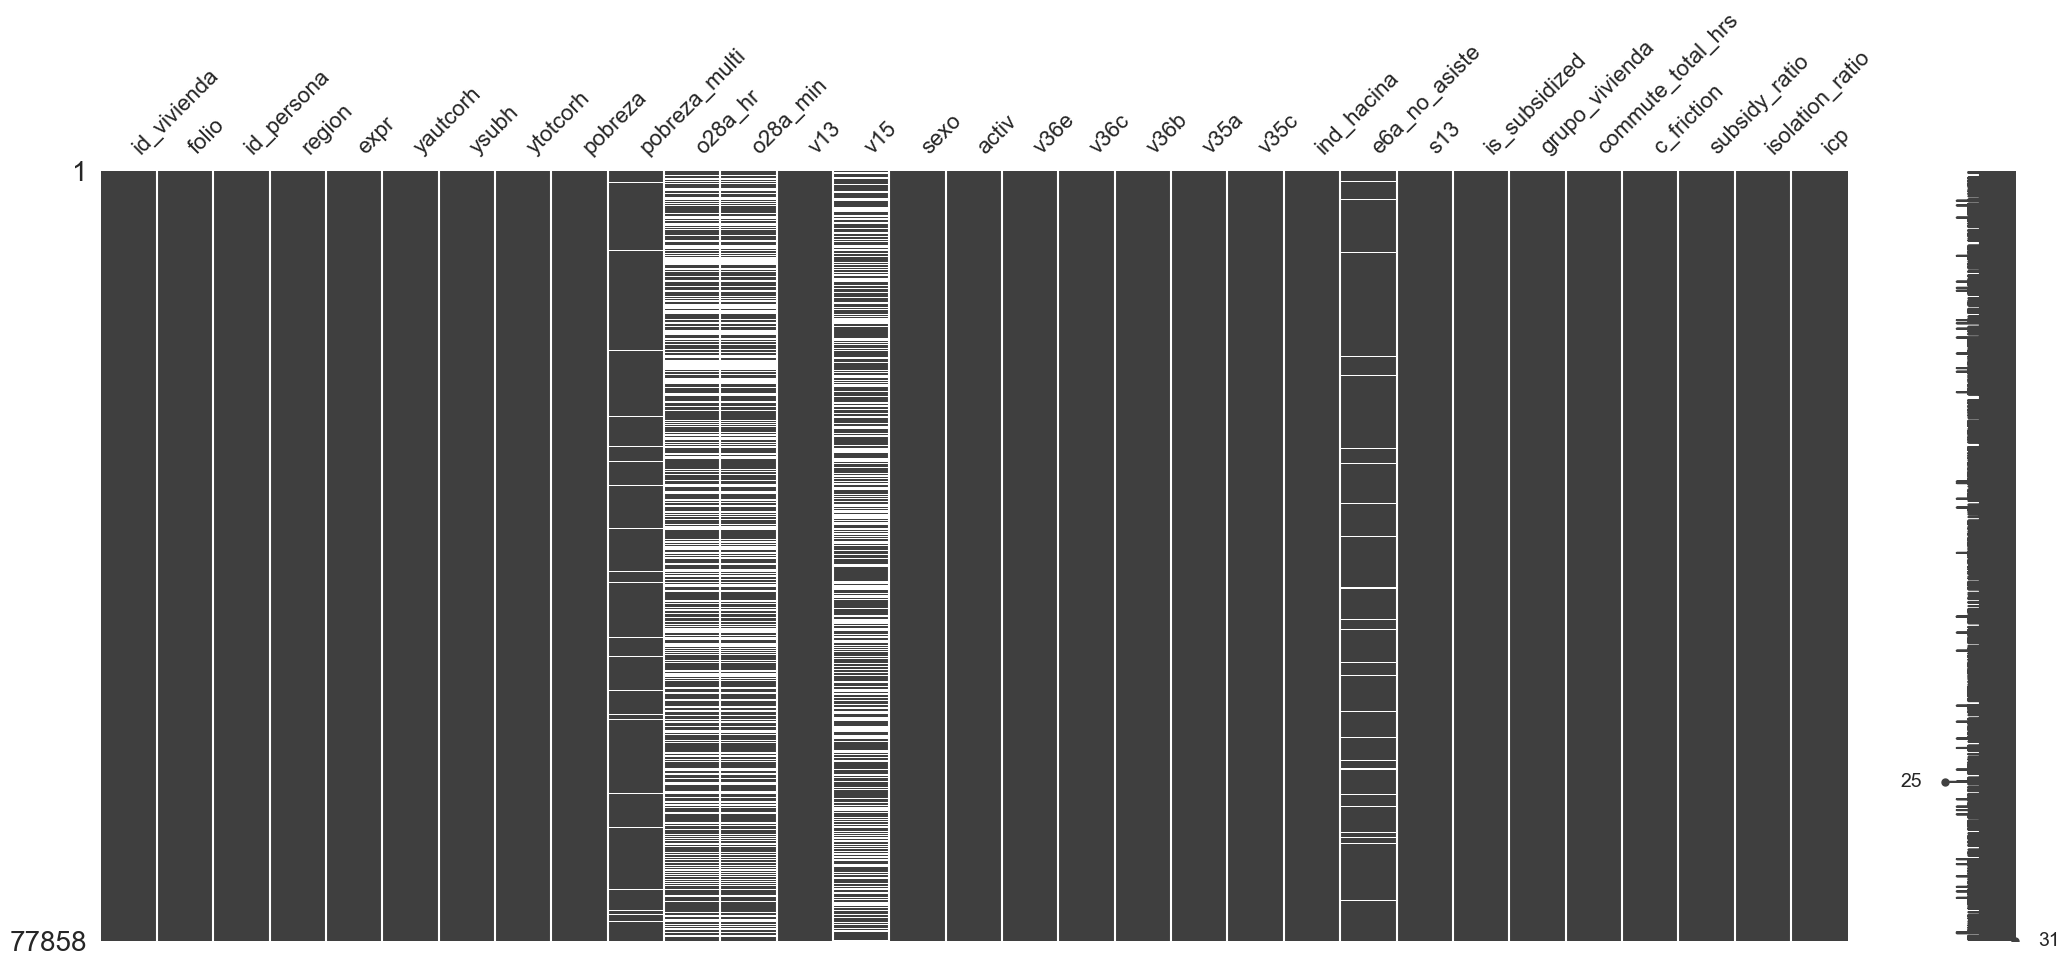

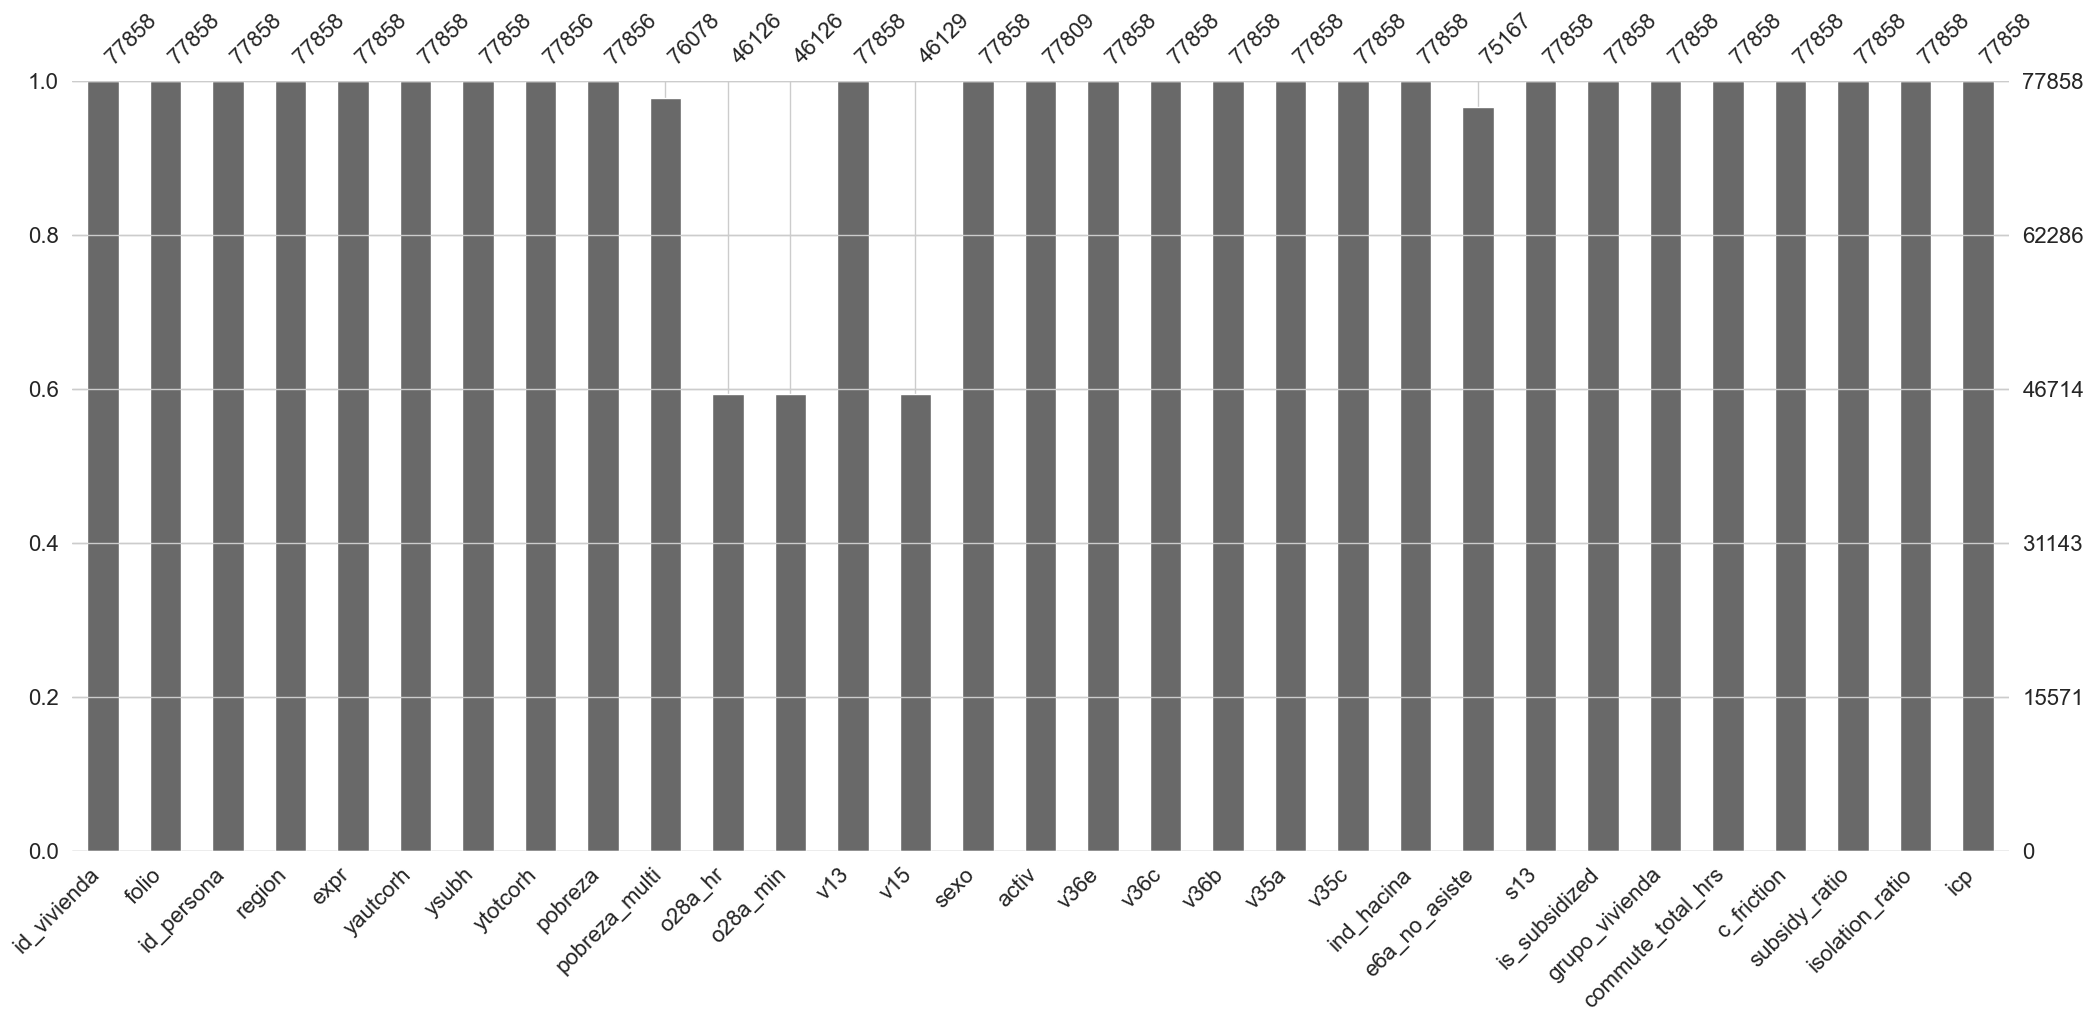

In [41]:
import missingno as msno
# 2. Visualizar la matriz de valores nulos
msno.matrix(df)
plt.show()

# 3. O un gráfico de barras para ver el porcentaje de completitud
msno.bar(df)
plt.show()

A continuacion se se creó u boxplot para analizar algunos outliers

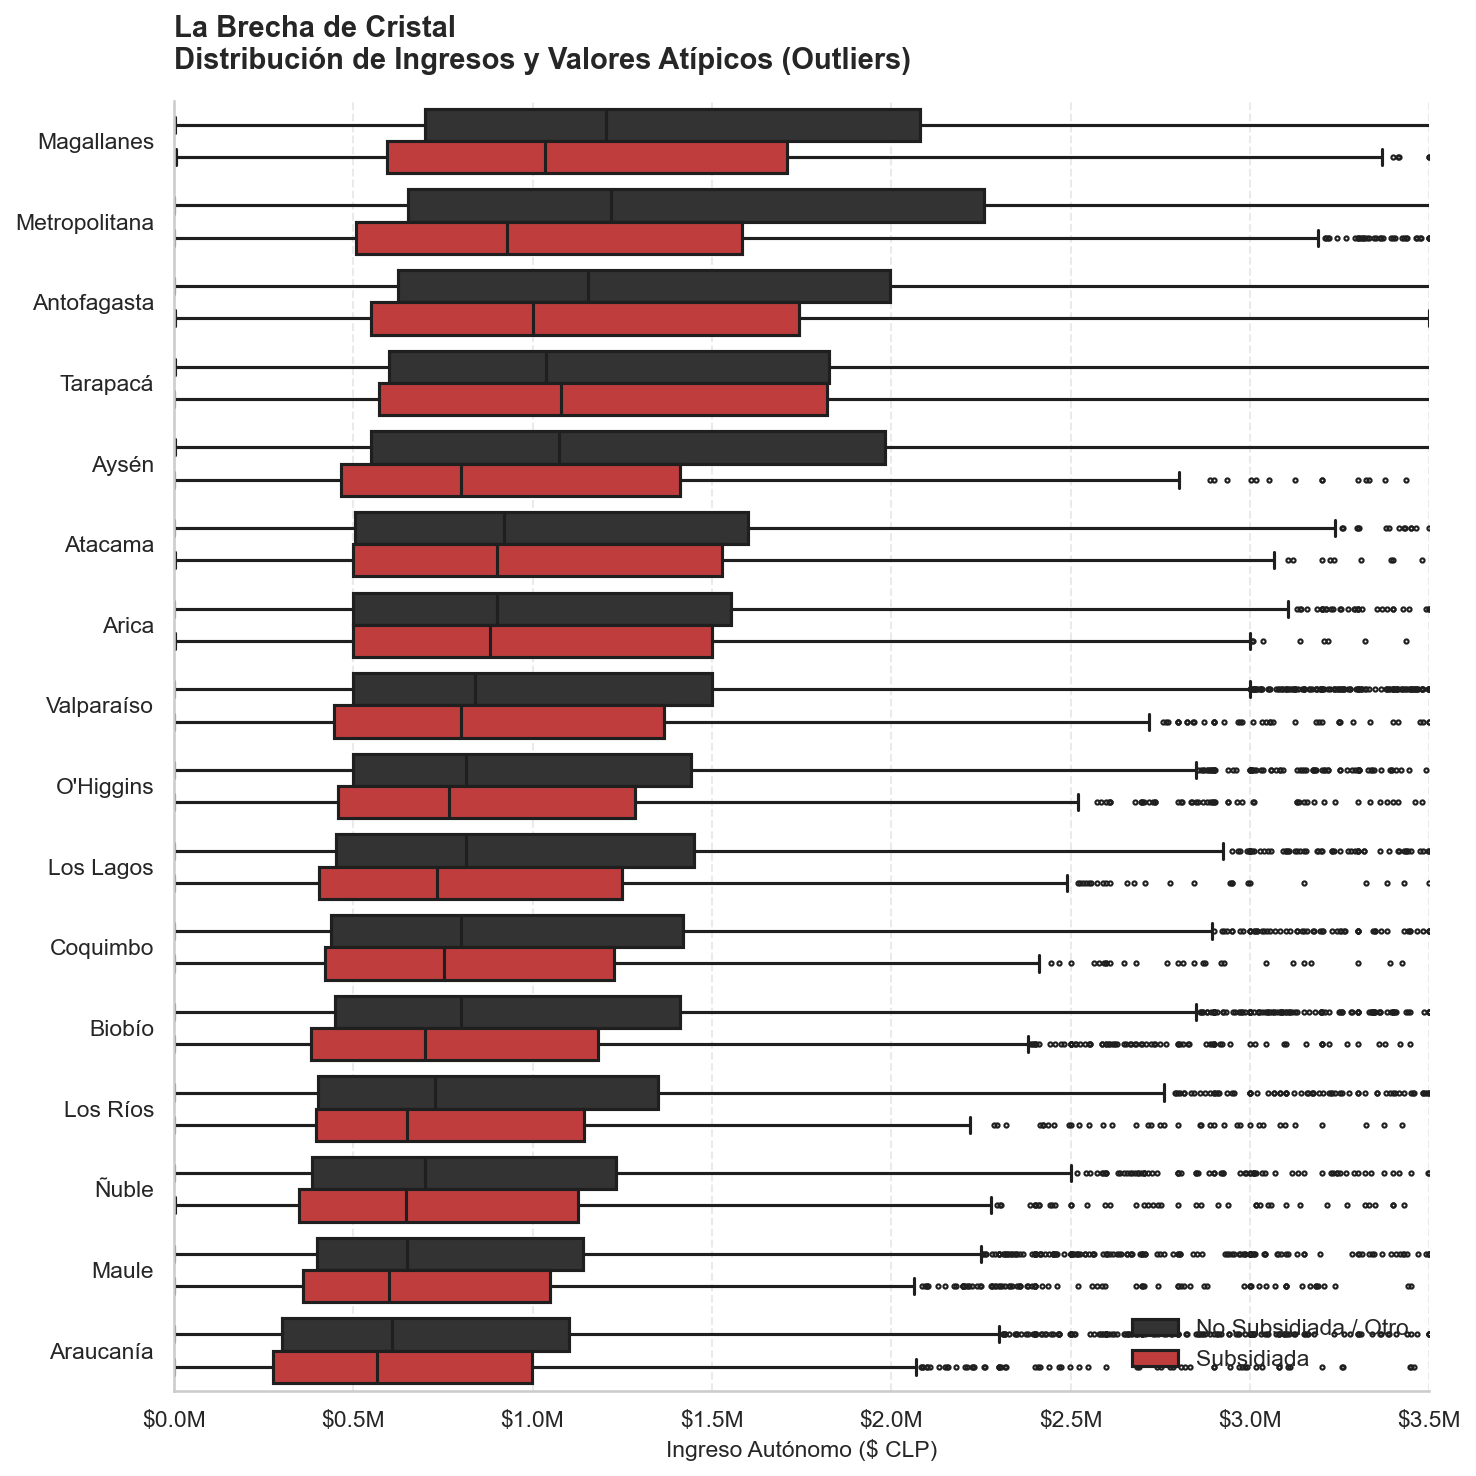

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Cargar el Master Dataset
df = pd.read_parquet(r"../data/processed/master_dataset.parquet")
df = df[df['grupo_vivienda'].isin(['Subsidiada', 'No Subsidiada / Otro'])]

# Mapear regiones para que se entiendan
region_map = {1:"Tarapacá", 2:"Antofagasta", 3:"Atacama", 4:"Coquimbo", 5:"Valparaíso", 6:"O'Higgins", 7:"Maule", 8:"Biobío", 9:"Araucanía", 10:"Los Lagos", 11:"Aysén", 12:"Magallanes", 13:"Metropolitana", 14:"Los Ríos", 15:"Arica", 16:"Ñuble"}
df['region_name'] = df['region'].map(region_map)

# 2. Limpiar Ceros y aislar el Ingreso Autónomo
df_inc = df[df['yautcorh'] > 0].copy()

# Ordenar las regiones por la mediana de ingreso total para que el gráfico tenga un orden lógico ascendente
orden_regiones = df_inc.groupby('region_name')['yautcorh'].median().sort_values(ascending=False).index

# 3. Canvas y Estilos
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
c_sub = "#d62728"   # Rojo sangre (Subsidio)
c_nosub = "#333333" # Gris oscuro (Privado)

# 4. Dibujar las Cajas (Seaborn hace el Boxplot multivariable en 1 línea)
sns.boxplot(
    data=df_inc,
    x='yautcorh', 
    y='region_name',
    hue='grupo_vivienda',
    order=orden_regiones, # De la región más rica a la más pobre
    palette={'Subsidiada': c_sub, 'No Subsidiada / Otro': c_nosub},
    fliersize=2, # Tamaño de los puntos "outliers"
    linewidth=1.5,
    ax=ax
)

# 5. Maquillaje Final
ax.set_title('La Brecha de Cristal\nDistribución de Ingresos y Valores Atípicos (Outliers)', loc='left', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ingreso Autónomo ($ CLP)', fontsize=11)
ax.set_ylabel('') # La y ya tiene los nombres de las regiones

# Formato del Eje X en Millones de Pesos para leerlo fácil
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1000000:.1f}M'))

# LIMITE VITAL: Cortar el límite visual en 3.5 Millones. Si no haces esto, los súper millonarios aplastarán tus cajas.
ax.set_xlim(0, 3500000)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Configurar leyenda
ax.legend(title='', loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


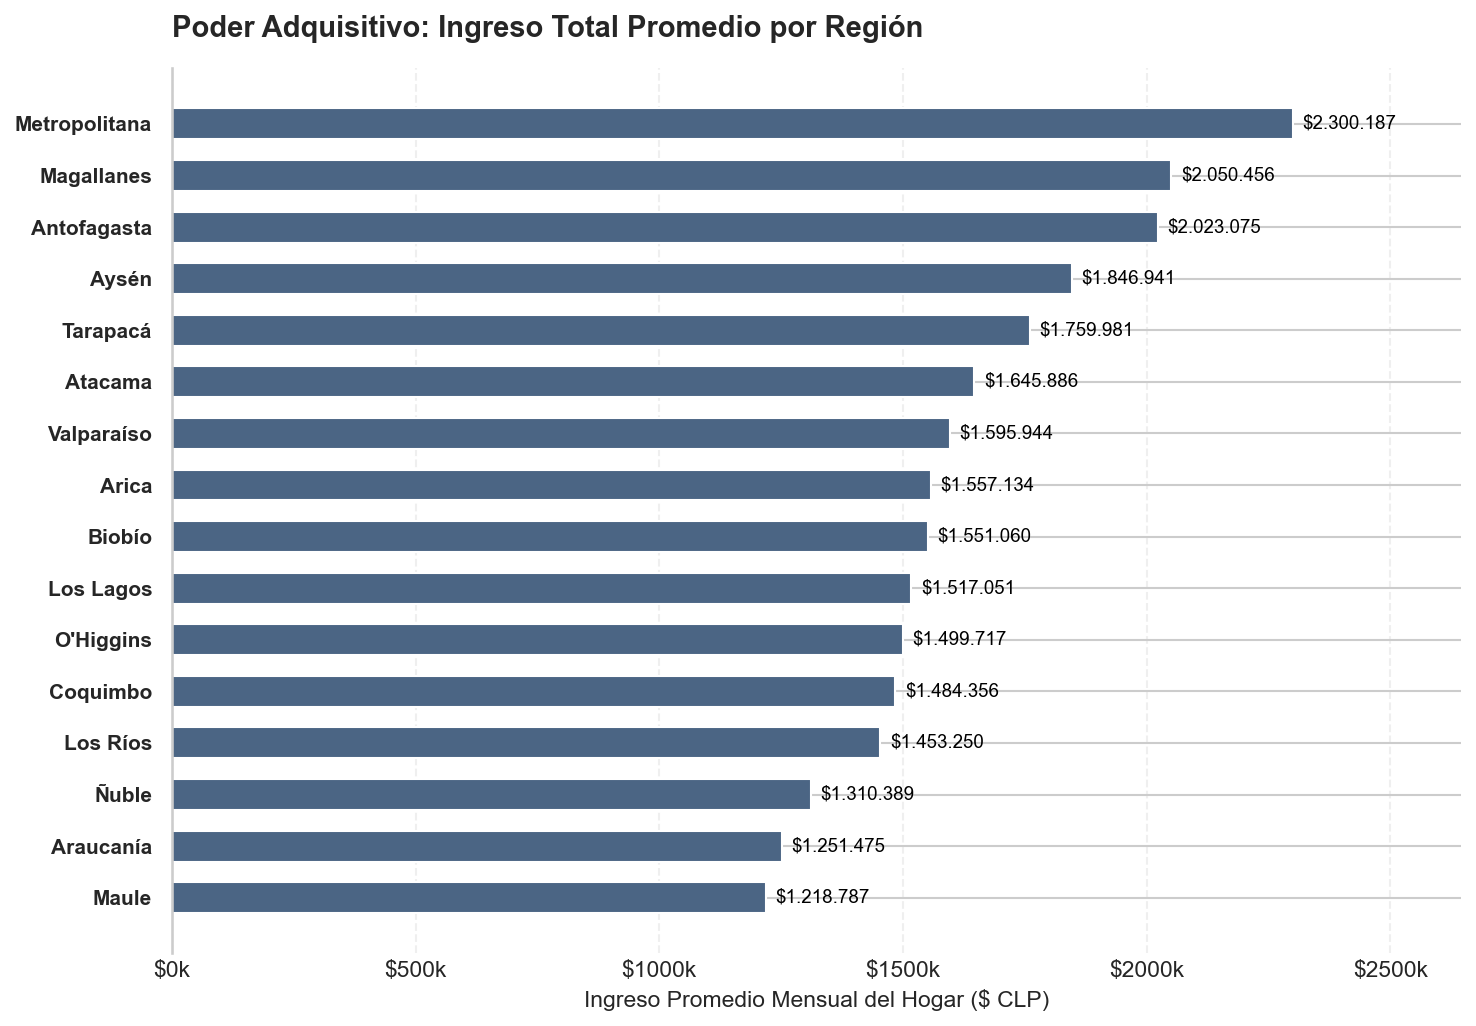

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el Master Dataset
df = pd.read_parquet(r"../data/processed/master_dataset.parquet")

# Limpiar valores nulos en el Ingreso Total
df_inc = df.dropna(subset=['ytotcorh']).copy()

# 2. Mapeo de Regiones
region_map = {
    1: "Tarapacá", 2: "Antofagasta", 3: "Atacama", 4: "Coquimbo", 5: "Valparaíso", 
    6: "O'Higgins", 7: "Maule", 8: "Biobío", 9: "Araucanía", 10: "Los Lagos", 
    11: "Aysén", 12: "Magallanes", 13: "Metropolitana", 14: "Los Ríos", 15: "Arica", 16: "Ñuble"}

df_inc['region_name'] = df_inc['region'].map(region_map)

# 3. Calcular el Promedio Ponderado Oficial
def weighted_income(x):
    return pd.Series({'Ingreso Promedio': np.average(x['ytotcorh'], weights=x['expr'])})

res_inc = df_inc.groupby('region_name').apply(weighted_income).sort_values(by='Ingreso Promedio', ascending=True)

# 4. Configurar el Canvas
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# Para hacerlo más elegante, colorearemos de un gris neutro y dejaremos en Rojo o Azul la más rica/pobre si quieres
color_barras = "#4B6584"

# 5. Dibujar las Barras Horizontales
y_pos = np.arange(len(res_inc))
valores = res_inc['Ingreso Promedio']

bars = ax.barh(y_pos, valores, color=color_barras, height=0.6)

# 6. Añadir los montos de dinero pegados a cada barra
import matplotlib.ticker as ticker
for i, bar in enumerate(bars):
    # Formatearlo hermosamente (ej: $1.200.000)
    ancho = bar.get_width()
    ax.text(ancho + 20000, bar.get_y() + bar.get_height()/2, 
            f"${int(ancho):,}".replace(",", "."), # Formato chileno
            va='center', color='black', fontsize=9)

# 7. Maquillaje Final
ax.set_yticks(y_pos)
ax.set_yticklabels(res_inc.index, fontsize=10, fontweight='bold')
ax.set_title('Poder Adquisitivo: Ingreso Total Promedio por Región', loc='left', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ingreso Promedio Mensual del Hogar ($ CLP)', fontsize=11)

# Quitar las notaciones científicas y poner "Millones"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# Limpiar bordes estéticos
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', length=0)
ax.set_xlim(0, valores.max() * 1.15) # Dar aire para el texto

plt.tight_layout()
plt.show()


a continuacion se creo un grafico que mezcla las regiones,el nivel de pobreza y si la vivienda es subsidiada o no 

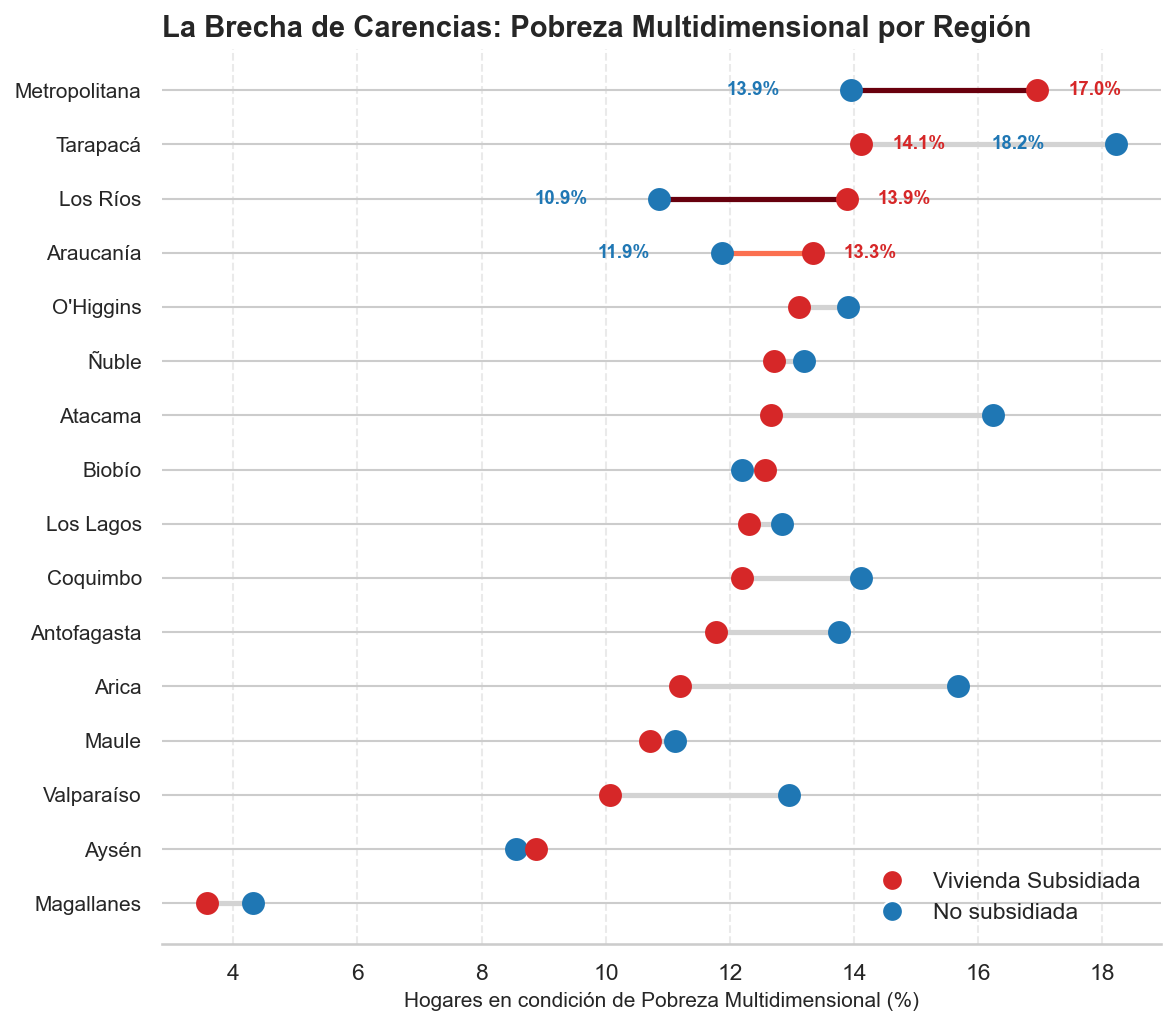

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Cargar el Master Dataset
# 2. Mapeo de Regiones
region_map = {
    1: "Tarapacá", 2: "Antofagasta", 3: "Atacama", 4: "Coquimbo", 5: "Valparaíso", 
    6: "O'Higgins", 7: "Maule", 8: "Biobío", 9: "Araucanía", 10: "Los Lagos", 
    11: "Aysén", 12: "Magallanes", 13: "Metropolitana", 14: "Los Ríos", 15: "Arica", 16: "Ñuble"}

df['region_name'] = df['region'].map(region_map)

# En Casen, la pobreza multidimensional suele usar códigos específicos (asumiremos que estar en la categoría de pobreza es el código 1.0)
# Para no fallar, extraemos del ponderador a los que sí están clasificados como pobres.
df_pobreza = df.dropna(subset=['pobreza_multi', 'region_name']).copy()

# En algunas ediciones de Casen el pobre es 1, o 1 y 2. Si tu base marca '1' como pobre multidimensional:
df_pobreza['es_pobre'] = df_pobreza['pobreza_multi'] == 1.0  

# 3. Calcular Promedios Ponderados (Factor de expansión Casen)
def weighted_pobreza(x):
    return np.average(x['es_pobre'], weights=x['expr']) * 100

grp = df_pobreza.groupby(['region_name', 'grupo_vivienda']).apply(weighted_pobreza).unstack()

# Sacamos la brecha para ordenar: cuánto castiga el subsidio vs el privado
grp['Brecha'] = grp['Subsidiada'] - grp['No Subsidiada / Otro']
grp = grp.sort_values(by='Subsidiada', ascending=True)

# 4. Parámetros Visuales
c_sub = "#d62728"   # Rojo Pobreza
c_nosub = "#1f77b4" # Azul Privado
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
y_r = np.arange(len(grp))

# Mapa de Calor para mostrar la urgencia de la brecha
norm = mcolors.Normalize(vmin=0, vmax=grp['Brecha'].max())
cmap = plt.colormaps.get_cmap('Reds')

# 5. Dibujar el Dumbbell Plot (Gráfico de pesas)
for i, (idx, row) in enumerate(grp.iterrows()):
    # Si la brecha es positiva (peor subsidio), se tinta rojo, sino gris.
    color = cmap(norm(row['Brecha'])) if row['Brecha'] > 0 else 'lightgrey'
    
    # Línea conectora
    ax.plot([row['No Subsidiada / Otro'], row['Subsidiada']], [i, i], color=color, linewidth=2.5, zorder=1)
    
    # Puntos de extremo
    ax.scatter(row['No Subsidiada / Otro'], i, color=c_nosub, s=100, zorder=2)
    ax.scatter(row['Subsidiada'], i, color=c_sub, s=100, zorder=2)
    
    # Textos de impacto (Etiquetar las peores 4 regiones subsidiadas)
    if i >= len(grp) - 4:
        # Texto rojo (Subsidio)
        ax.text(row['Subsidiada'] + 0.5, i, f"{row['Subsidiada']:.1f}%", color=c_sub, va='center', fontweight='bold', fontsize=9)
        # Texto azul (Privado)
        ax.text(row['No Subsidiada / Otro'] - 2, i, f"{row['No Subsidiada / Otro']:.1f}%", color=c_nosub, va='center', fontweight='bold', fontsize=9)

# 6. Maquillaje Final del Gráfico
ax.set_yticks(y_r)
ax.set_yticklabels(grp.index, fontsize=10)
ax.set_title('La Brecha de Carencias: Pobreza Multidimensional por Región', loc='left', fontsize=14, fontweight='bold')
ax.set_xlabel('Hogares en condición de Pobreza Multidimensional (%)', fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right', 'left']].set_visible(False)

# Leyenda
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Vivienda Subsidiada', markerfacecolor=c_sub, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='No subsidiada', markerfacecolor=c_nosub, markersize=10)
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


## OTRO analisis

In [52]:
print("========== NARRATIVE ENGINE: COMBINATORIAL ANALYSIS ==========")
# Story 1: The Health Trap
print("\n--- STORY 1: PUBLIC HEALTH TRAP ---")
# s13: 1=FONASA, 2=FFAA, 3=ISAPRE
df_health = df.dropna(subset=['s13']).copy()
df_health['is_isapre'] = df_health['s13'] == 3
df_health['is_fonasa'] = df_health['s13'] == 1
health_res = df_health.groupby('grupo_vivienda').apply(
    lambda x: pd.Series({
        '% en ISAPRE': np.average(x['is_isapre'], weights=x['expr']) * 100,
        '% en FONASA': np.average(x['is_fonasa'], weights=x['expr']) * 100
    })
).round(1)
print(health_res)

# Story 2: Extreme Danger & Extreme Poverty (ICP + Shootings)
print("\n--- STORY 3: CAUTIVERIO PATRIMONIAL (ICP) VS BALACERAS ---")
df['balaceras_frecuentes'] = df['v36e'].isin([3, 4])
icp_danger = df.dropna(subset=['v36e']).groupby(['grupo_vivienda', 'balaceras_frecuentes']).apply(
    lambda x: pd.Series({
        'ICP Promedio': np.average(x['icp'], weights=x['expr'])
    })
).unstack().round(1)
print(icp_danger)
# Story 4: The Core Hypothesis (Subsidy Ratio vs Friction Ratio)
print("\n--- STORY 4: FRICTION VS SUBSIDY DEPENDENCY ---")
core_res = df.groupby('grupo_vivienda').apply(
    lambda x: pd.Series({
        'Subsidy Ratio (Base 100)': np.average(x['subsidy_ratio'], weights=x['expr']) * 100,
        'Isolation Friction Ratio (Base 100)': np.average(x['isolation_ratio'], weights=x['expr']) * 100
    })
).round(1)
print(core_res)

========== NARRATIVE ENGINE: COMBINATORIAL ANALYSIS ==========

--- STORY 1: PUBLIC HEALTH TRAP ---
                      % en ISAPRE  % en FONASA
grupo_vivienda                                
No Subsidiada / Otro         2.10        78.70
Subsidiada                   1.90        88.70

--- STORY 3: CAUTIVERIO PATRIMONIAL (ICP) VS BALACERAS ---
                     ICP Promedio      
balaceras_frecuentes        False True 
grupo_vivienda                         
No Subsidiada / Otro         8.00  9.40
Subsidiada                   9.20 10.30

--- STORY 4: FRICTION VS SUBSIDY DEPENDENCY ---
                      Subsidy Ratio (Base 100)  \
grupo_vivienda                                   
No Subsidiada / Otro                      7.60   
Subsidiada                               10.80   

                      Isolation Friction Ratio (Base 100)  
grupo_vivienda                                             
No Subsidiada / Otro                                 8.80  
Subsidiada            

## otro analisis 

Jefes de Hogar en Mercado Privado: El 43.2% tiene algún nivel de Educación Superior. (Casi la mitad).
Jefes de Hogar Subsidiados: Apenas el 24.0%.

C:\Users\carlo\AppData\Local\Temp\ipykernel_25844\752496341.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(grupos, fontsize=11, fontweight='bold')


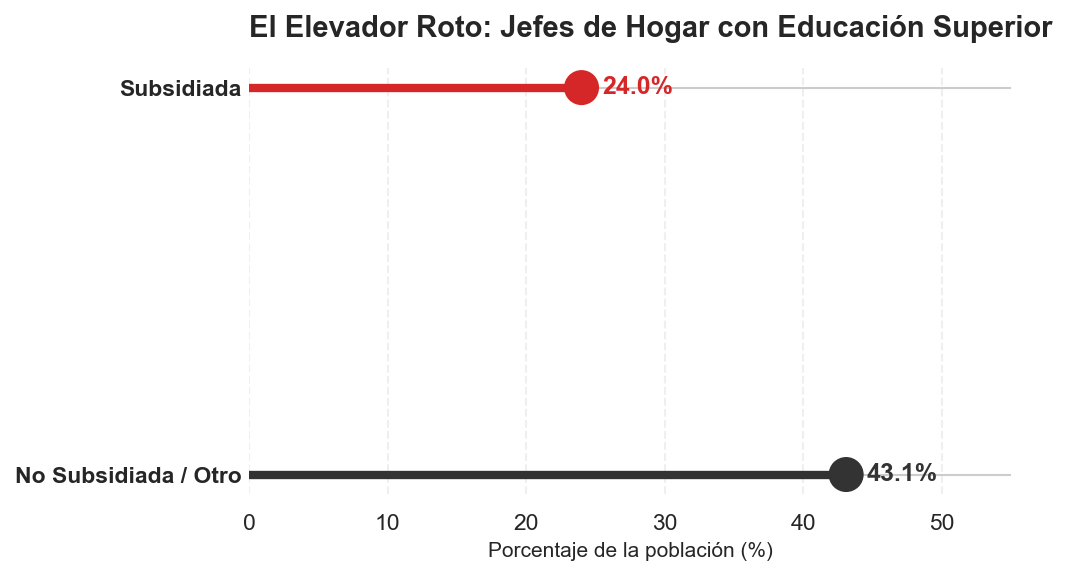

In [62]:

# 2. El Filtro Corregido: Educación Superior (Niveles >= 12)
df['edu_superior'] = df['e6a_no_asiste'] >= 12
df_edu = df.dropna(subset=['e6a_no_asiste']).copy()

# 3. Calcular la media ponderada (usando factor de expansión)
def weighted_edu(x):
    return pd.Series({'% Con Educación Superior': np.average(x['edu_superior'], weights=x['expr']) * 100})

res = df_edu.groupby('grupo_vivienda').apply(weighted_edu).round(1).reset_index()

# 4. Parámetros Visuales
c_sub = "#d62728"   # Rojo Sangre
c_nosub = "#333333" # Gris Oscuro
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# Asignar variables a los ejes
grupos = res['grupo_vivienda']
valores = res['% Con Educación Superior']

# 5. Dibujar el Gráfico "Lollipop" (Líneas + Puntos Grandes)
# Usamos vlines (líneas verticales u horizontales) para mayor elegancia
ax.hlines(y=grupos, xmin=0, xmax=valores, color=[c_nosub, c_sub], linewidth=4, zorder=1)
ax.scatter(valores, grupos, color=[c_nosub, c_sub], s=250, zorder=2)

# Añadir el texto enorme adentro de los puntos
for i, val in enumerate(valores):
    color_punto = c_nosub if i == 0 else c_sub
    # Poner el texto justo afuera de la "paleta" o encima
    ax.text(val + 1.5, i, f"{val}%", color=color_punto, fontsize=12, fontweight='bold', va='center')

# 6. Maquillaje Final (Cumpliendo la rúbrica de poca carga cognitiva)
ax.set_title('El Elevador Roto: Jefes de Hogar con Educación Superior', loc='left', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Porcentaje de la población (%)', fontsize=10)
# Quitar todos los bordes para mayor estética
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_xlim(0, 55) # Dar un poco de espacio en la derecha
ax.tick_params(axis='y', length=0) # Quitar rayitas del eje Y

# Hacer más grande y negra la etiqueta de los ejes Y
ax.set_yticklabels(grupos, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [63]:

# Mantener solo a los dos grupos que estamos comparando
df = df[df['grupo_vivienda'].isin(['Subsidiada', 'No Subsidiada / Otro'])]

print("--- EXPLORACIÓN MACRO: BUSCANDO LA HISTORIA ---")

print("\n1. POBREZA MULTIDIMENSIONAL (La Carencia Real)")
print(df.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    '% Pobres Multidimensionales': np.average(x['pobreza_multi'].isin([1.0, 2.0]), weights=x['expr']) * 100 if pd.notna(x['pobreza_multi']).any() else 0
})).round(1))

print("\n2. DEPENDENCIA PURA (El Sueldo del Estado)")
# ¿Qué porcentaje de todos los ingresos de la casa vienen de Bonos/Subsidios?
print(df.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    '% del Ingreso proveniente de Bonos/Estado': np.average((x['ysubh'] / x['ytotcorh'].replace(0, np.nan)).fillna(0), weights=x['expr']) * 100
})).round(1))

print("\n3. TIEMPO PERDIDO AL AÑO (Segregación Espacial Continua)")
# Asumiendo commute_total_hrs es mensual
print(df.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Horas perdidas al AÑO en transporte': np.average(x['commute_total_hrs'], weights=x['expr']) * 12
})).round(0))

print("\n4. SISTEMA DE SALUD PÚBLICA ESTANCADO (FONASA)")
# s13 == 1 es Fonasa
print(df.dropna(subset=['s13']).groupby('grupo_vivienda').apply(lambda x: pd.Series({
    '% Atrapados en FONASA': np.average(x['s13']==1, weights=x['expr']) * 100
})).round(1))

print("\n5. EDUCACIÓN: LA JUVENTUD (Abandono/Estancamiento)")
# Si no queremos hablar solo de mujeres, hablemos de Capital Humano Total
# % de Jefes de hogar que NUNCA pasaron de Educación Básica (códigos <= 6)
# o Educación Media Incompleta.
print(df.dropna(subset=['e6a_no_asiste']).groupby('grupo_vivienda').apply(lambda x: pd.Series({
    '% Con Escasa Preparación (Máximo Ed. Básica o nula)': np.average(x['e6a_no_asiste'] <= 6, weights=x['expr']) * 100,
    '% Con Educación Superior Alcanzada': np.average(x['e6a_no_asiste'] >= 13, weights=x['expr']) * 100
})).round(1))

print("\n6. HACINAMIENTO CRÍTICO A PESAR DEL SUBSIDIO")
print(df.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    '% Hogares con algún grado de Hacinamiento': np.average(x['ind_hacina'].isin([2, 3, 4]), weights=x['expr']) * 100
})).round(1))

print("\n7. LA SUMA DE TODOS LOS MIEDOS: BALACERAS + AISLAMIENTO")
# Cruzar "Vive lejos de transporte (v35a=2)" Y "Sufre balaceras frecuentes (3,4)"
df['pesadilla_urbana'] = (df['v36e'].isin([3, 4])) & (df['v35a'] == 2)
print(df.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    '% en Pesadilla (Balaceras + Sin Transporte Cerca)': np.average(x['pesadilla_urbana'], weights=x['expr']) * 100
})).round(1))



--- EXPLORACIÓN MACRO: BUSCANDO LA HISTORIA ---

1. POBREZA MULTIDIMENSIONAL (La Carencia Real)
                      % Pobres Multidimensionales
grupo_vivienda                                   
No Subsidiada / Otro                        13.10
Subsidiada                                  13.40

2. DEPENDENCIA PURA (El Sueldo del Estado)
                      % del Ingreso proveniente de Bonos/Estado
grupo_vivienda                                                 
No Subsidiada / Otro                                       7.60
Subsidiada                                                10.80

3. TIEMPO PERDIDO AL AÑO (Segregación Espacial Continua)
                      Horas perdidas al AÑO en transporte
grupo_vivienda                                           
No Subsidiada / Otro                               170.00
Subsidiada                                         155.00

4. SISTEMA DE SALUD PÚBLICA ESTANCADO (FONASA)
                      % Atrapados en FONASA
grupo_vivienda        


--- GENERANDO VISUALIZACIONES MACRO ---


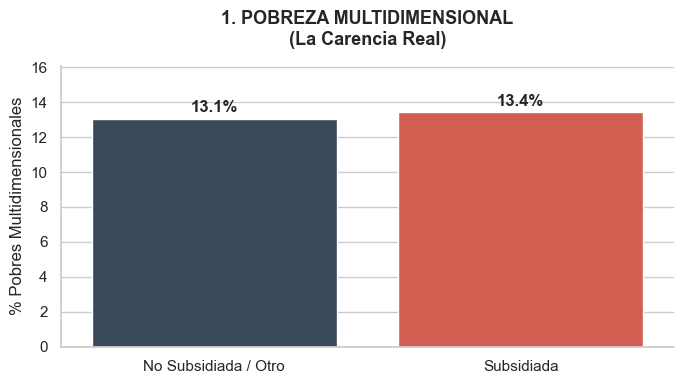

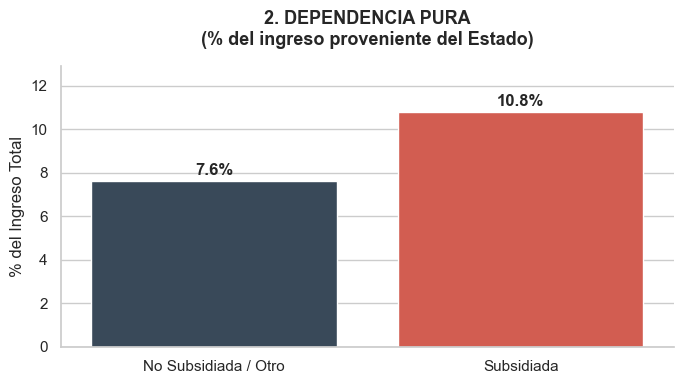

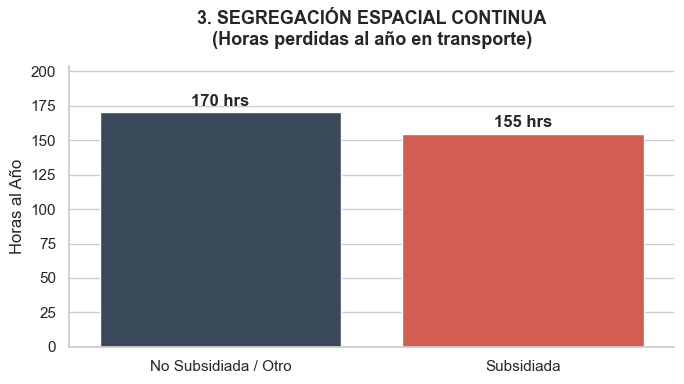

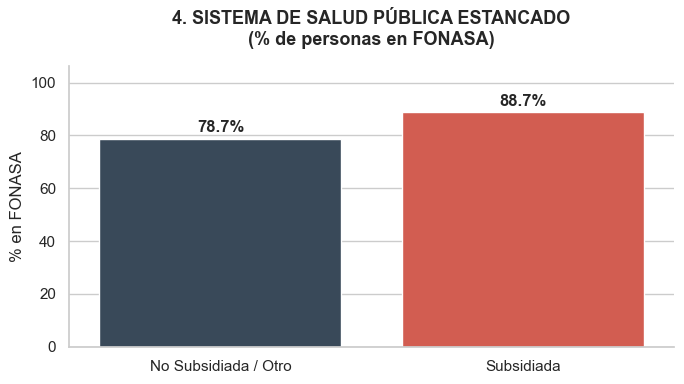

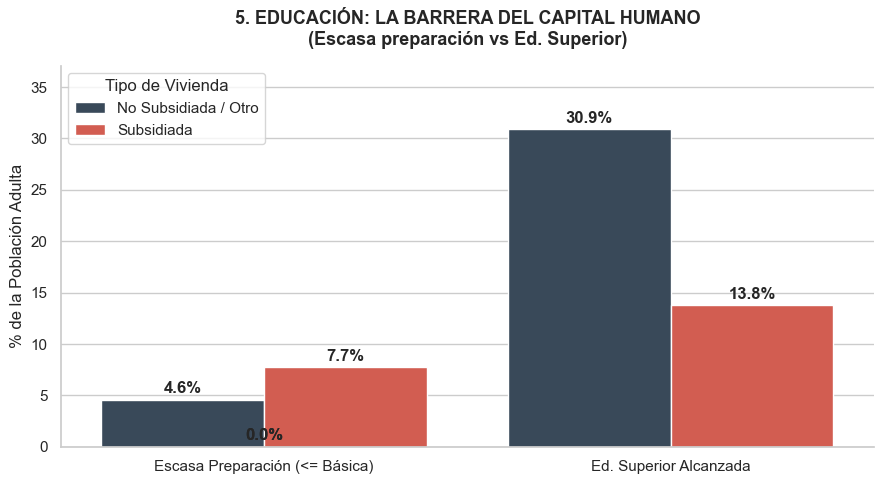

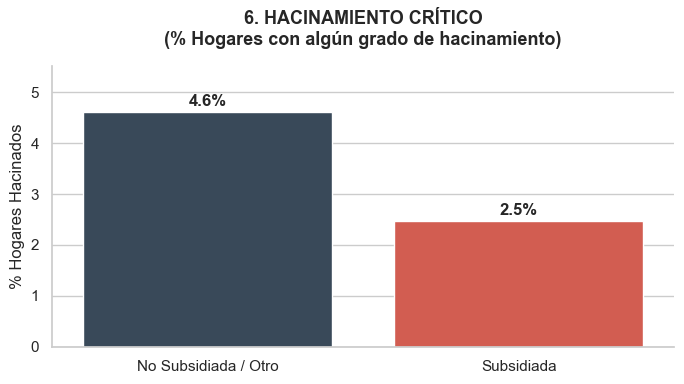

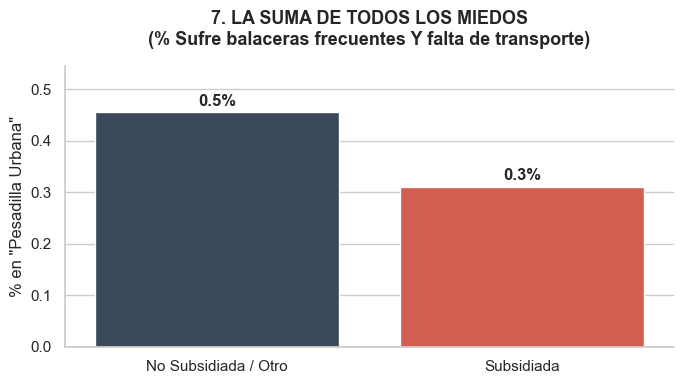

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
paleta_colores = {'No Subsidiada / Otro': '#34495e', 'Subsidiada': '#e74c3c'} # Gris y Rojo

# 0. Filtrar dataframe
df_plot = df[df['grupo_vivienda'].isin(['Subsidiada', 'No Subsidiada / Otro'])].copy()

# =====================================================================
# CÁLCULOS (Usando exactamente tu lógica con factor de expansión)
# =====================================================================

# 1. Pobreza
res_pobreza = df_plot.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Valor': np.average(x['pobreza_multi'].isin([1.0, 2.0]), weights=x['expr']) * 100 if pd.notna(x['pobreza_multi']).any() else 0
})).reset_index()

# 2. Dependencia Pura
res_dep = df_plot.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Valor': np.average((x['ysubh'] / x['ytotcorh'].replace(0, np.nan)).fillna(0), weights=x['expr']) * 100
})).reset_index()

# 3. Tiempo Perdido
res_tiempo = df_plot.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Valor': np.average(x['commute_total_hrs'], weights=x['expr']) * 12
})).reset_index()

# 4. Salud
res_salud = df_plot.dropna(subset=['s13']).groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Valor': np.average(x['s13']==1, weights=x['expr']) * 100
})).reset_index()

# 5. Educación (Doble métrica)
res_edu = df_plot.dropna(subset=['e6a_no_asiste']).groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Escasa Preparación (<= Básica)': np.average(x['e6a_no_asiste'] <= 6, weights=x['expr']) * 100,
    'Ed. Superior Alcanzada': np.average(x['e6a_no_asiste'] >= 13, weights=x['expr']) * 100
})).reset_index().melt(id_vars='grupo_vivienda', var_name='Nivel', value_name='Valor')

# 6. Hacinamiento
res_hacina = df_plot.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Valor': np.average(x['ind_hacina'].isin([2, 3, 4]), weights=x['expr']) * 100
})).reset_index()

# 7. Pesadilla Urbana
df_plot['pesadilla_urbana'] = (df_plot['v36e'].isin([3, 4])) & (df_plot['v35a'] == 2)
res_pesadilla = df_plot.groupby('grupo_vivienda').apply(lambda x: pd.Series({
    'Valor': np.average(x['pesadilla_urbana'], weights=x['expr']) * 100
})).reset_index()


# =====================================================================
# FUNCIÓN PARA DIBUJAR GRÁFICOS SIMPLES CON ETIQUETAS
# =====================================================================
def plot_indicador(data, titulo, ylabel, es_porcentaje=True):
    plt.figure(figsize=(7, 4))
    ax = sns.barplot(data=data, x='grupo_vivienda', y='Valor', hue='grupo_vivienda', palette=paleta_colores, legend=False)
    plt.title(titulo, fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('')
    plt.ylabel(ylabel)
    
    # Agregar los números sobre las barras
    for p in ax.patches:
        formato = '{:.1f}%' if es_porcentaje else '{:.0f} hrs'
        ax.annotate(formato.format(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 8), 
                    textcoords = 'offset points', fontweight='bold')
    plt.ylim(0, data['Valor'].max() * 1.2) # Dar espacio para el texto
    plt.tight_layout()
    plt.show()

# =====================================================================
# GENERACIÓN DE LOS 7 GRÁFICOS
# =====================================================================

print("\n--- GENERANDO VISUALIZACIONES MACRO ---")

plot_indicador(res_pobreza, '1. POBREZA MULTIDIMENSIONAL\n(La Carencia Real)', '% Pobres Multidimensionales')
plot_indicador(res_dep, '2. DEPENDENCIA PURA\n(% del ingreso proveniente del Estado)', '% del Ingreso Total')
plot_indicador(res_tiempo, '3. SEGREGACIÓN ESPACIAL CONTINUA\n(Horas perdidas al año en transporte)', 'Horas al Año', es_porcentaje=False)
plot_indicador(res_salud, '4. SISTEMA DE SALUD PÚBLICA ESTANCADO\n(% de personas en FONASA)', '% en FONASA')

# Gráfico 5 es especial porque tiene dos barras por grupo (Educación agrupada)
plt.figure(figsize=(9, 5))
ax5 = sns.barplot(data=res_edu, x='Nivel', y='Valor', hue='grupo_vivienda', palette=paleta_colores)
plt.title('5. EDUCACIÓN: LA BARRERA DEL CAPITAL HUMANO\n(Escasa preparación vs Ed. Superior)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('% de la Población Adulta')
for p in ax5.patches:
    ax5.annotate('{:.1f}%'.format(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 8), 
                textcoords = 'offset points', fontweight='bold')
plt.ylim(0, res_edu['Valor'].max() * 1.2)
plt.legend(title='Tipo de Vivienda')
plt.tight_layout()
plt.show()

plot_indicador(res_hacina, '6. HACINAMIENTO CRÍTICO\n(% Hogares con algún grado de hacinamiento)', '% Hogares Hacinados')
plot_indicador(res_pesadilla, '7. LA SUMA DE TODOS LOS MIEDOS\n(% Sufre balaceras frecuentes Y falta de transporte)', '% en "Pesadilla Urbana"')

A continuación algo interesante, familias que reportan balacera 


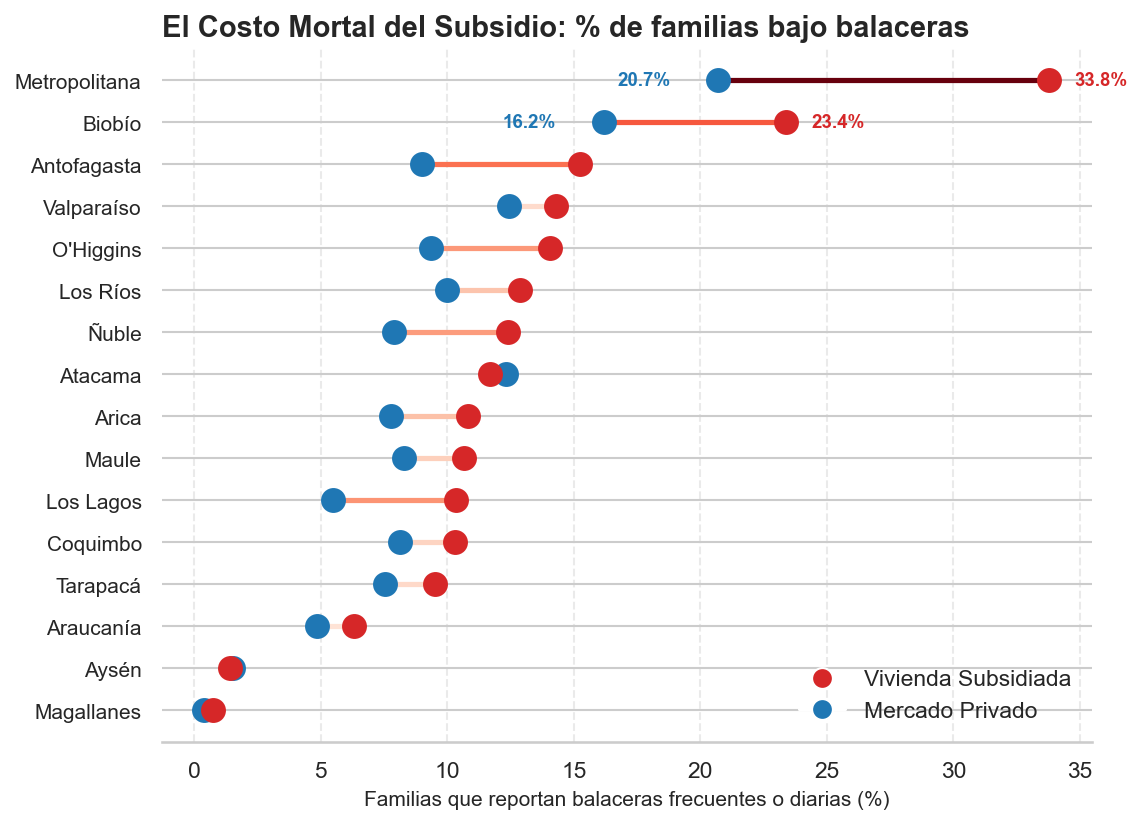

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# 2. Mapeo de Regiones y Filtrado
region_map = {
    1: "Tarapacá", 2: "Antofagasta", 3: "Atacama", 4: "Coquimbo", 5: "Valparaíso", 
    6: "O'Higgins", 7: "Maule", 8: "Biobío", 9: "Araucanía", 10: "Los Lagos", 
    11: "Aysén", 12: "Magallanes", 13: "Metropolitana", 14: "Los Ríos", 15: "Arica", 16: "Ñuble"}

df['region_name'] = df['region'].map(region_map)
df['balaceras_frecuentes'] = df['v36e'].isin([3, 4])
df_bala = df.dropna(subset=['v36e', 'region_name']).copy()

# 3. Calcular Promedios Ponderados (Casen siempre usa el 'expr')
def weighted_balaceras(x):
    return np.average(x['balaceras_frecuentes'], weights=x['expr']) * 100

grp = df_bala.groupby(['region_name', 'grupo_vivienda']).apply(weighted_balaceras).unstack()
grp['Brecha'] = grp['Subsidiada'] - grp['No Subsidiada / Otro']
grp = grp.sort_values(by='Subsidiada', ascending=True)

# 4. Parámetros Visuales
c_sub = "#d62728"   # Rojo Sangre para Subsidio
c_nosub = "#1f77b4" # Azul Clásico para Privados
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
y_r = np.arange(len(grp))

# Mapa de Calor para mostrar la urgencia
norm = mcolors.Normalize(vmin=0, vmax=grp['Brecha'].max())
cmap = plt.colormaps.get_cmap('Reds')

# 5. Dibujar el Dumbbell Plot (Gráfico de pesas)
for i, (idx, row) in enumerate(grp.iterrows()):
    color = cmap(norm(row['Brecha'])) if row['Brecha'] > 0 else 'grey'
    
    # Línea conector
    ax.plot([row['No Subsidiada / Otro'], row['Subsidiada']], [i, i], color=color, linewidth=2.5, zorder=1)
    
    # Puntos de extremo
    ax.scatter(row['No Subsidiada / Otro'], i, color=c_nosub, s=120, zorder=2)
    ax.scatter(row['Subsidiada'], i, color=c_sub, s=120, zorder=2)
    
    # Textos de impacto (solo para los peores casos > 20%)
    if row['Subsidiada'] > 20:
        ax.text(row['Subsidiada'] + 1, i, f"{row['Subsidiada']:.1f}%", color=c_sub, va='center', fontweight='bold', fontsize=9)
        ax.text(row['No Subsidiada / Otro'] - 4, i, f"{row['No Subsidiada / Otro']:.1f}%", color=c_nosub, va='center', fontweight='bold', fontsize=9)

# 6. Maquillaje Final del Gráfico
ax.set_yticks(y_r)
ax.set_yticklabels(grp.index, fontsize=10)
ax.set_title('El Costo Mortal del Subsidio: % de familias bajo balaceras', loc='left', fontsize=14, fontweight='bold')
ax.set_xlabel('Familias que reportan balaceras frecuentes o diarias (%)', fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right', 'left']].set_visible(False)

# Leyenda
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Vivienda Subsidiada', markerfacecolor=c_sub, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Mercado Privado', markerfacecolor=c_nosub, markersize=10)
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=11)

plt.show()


En el fondo está Magallanes o Aysén donde no pasa absolutamente nada.
A medida que subes a los cerros de Valparaíso o al centro minero de Antofagasta, las distancias comienzan a estirarse demostrando que el estado te ubica en lugares peores.
Pero el final de la cuerda lo tienen la Región del Biobío y la Metropolitana, donde la escala de color rojo se vuelve brutal, exponiendo que 3 de cada 10 familias que el Estado "ayudó" deben lidiar con balas a diario.

### otro análisis


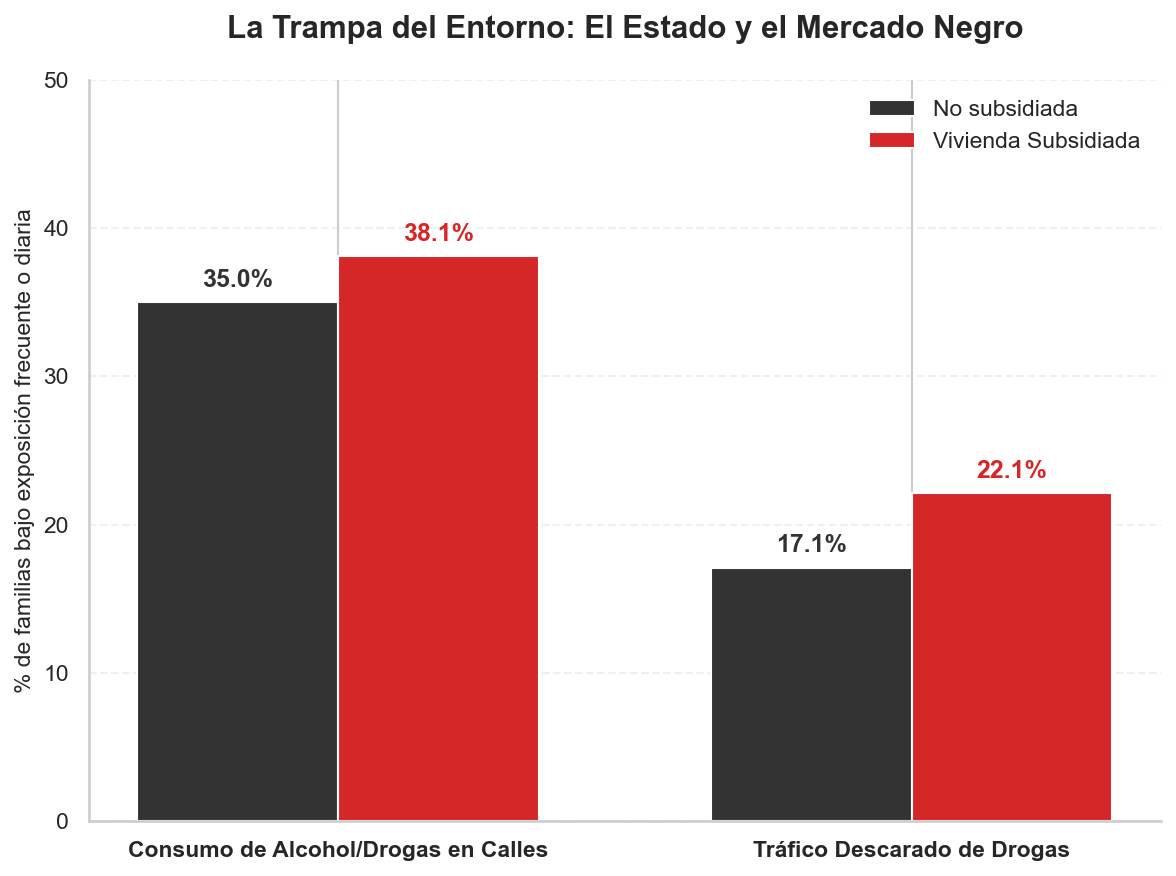

In [65]:
df = pd.read_parquet('../data/processed/master_dataset.parquet')
# 2. Resumir la crisis de Drogas (v36b: Consumo en calle, v36c: Tráfico)
# Consideramos 3 y 4 ("Frecuentemente" y "Siempre")
df['consumo_drogas'] = df['v36b'].isin([3, 4])
df['trafico_drogas'] = df['v36c'].isin([3, 4])
# Calcular ponderados con factor de expansión
def weighted_narco(x):
    return pd.Series({
        'Consumo de Alcohol/Drogas en Calles': np.average(x['consumo_drogas'], weights=x['expr']) * 100,
        'Tráfico Descarado de Drogas': np.average(x['trafico_drogas'], weights=x['expr']) * 100
    })
# Obtenemos los dataframes agrupados
grp = df.dropna(subset=['v36b', 'v36c']).groupby('grupo_vivienda').apply(weighted_narco).round(1).T
# 4. Parámetros Visuales y Set up
c_sub = "#d62728"   # Rojo Alerta
c_nosub = "#333333" # Gris Apagado
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
# Posiciones
x = np.arange(len(grp.index))
width = 0.35
# 5. Dibujar las barras
bar1 = ax.bar(x - width/2, grp['No Subsidiada / Otro'], width, label='No subsidiada', color=c_nosub)
bar2 = ax.bar(x + width/2, grp['Subsidiada'], width, label='Vivienda Subsidiada', color=c_sub)
# 6. Añadir los textos (Porcentajes) encima de las barras
def autolabel(rects, color_text='black'):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Desplazamiento
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', color=color_text)
autolabel(bar1, color_text='#333333')
autolabel(bar2, color_text=c_sub)
# 7. Maquillaje Final
ax.set_xticks(x)
ax.set_xticklabels(grp.index, fontsize=11, fontweight='bold')
ax.set_title('La Trampa del Entorno: El Estado y el Mercado Negro', loc='center', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('% de familias bajo exposición frecuente o diaria', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, 50) # Dar aire arriba para los textos
ax.legend(loc='upper right', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

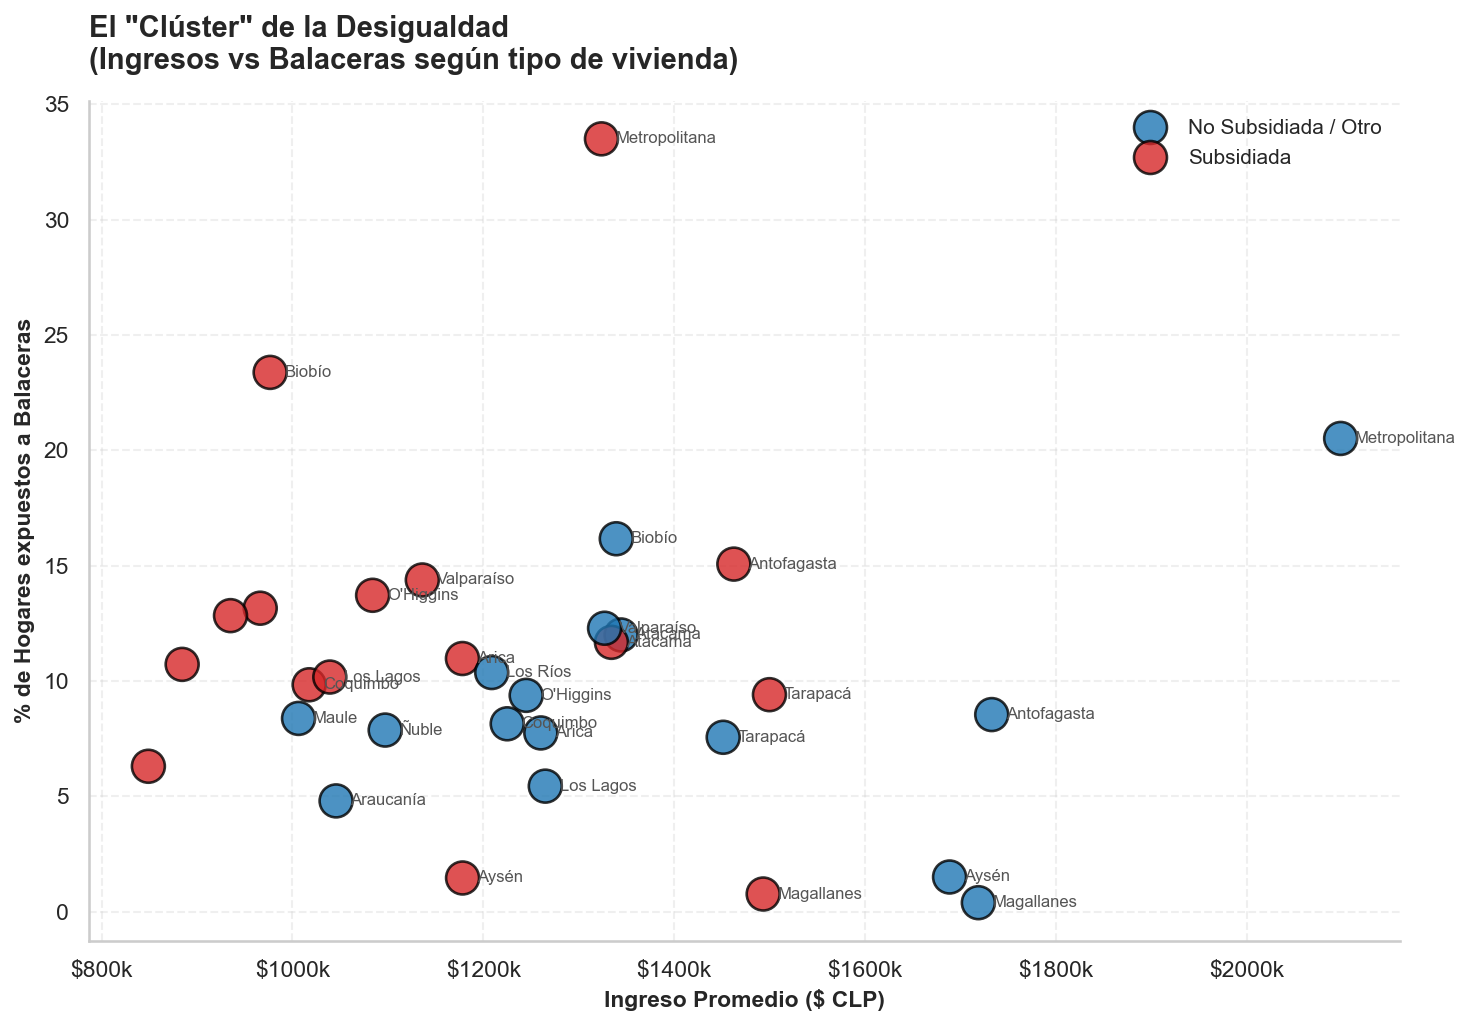

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el Master Dataset
df = pd.read_parquet(r"../data/processed/master_dataset.parquet")
df = df[df['grupo_vivienda'].isin(['Subsidiada', 'No Subsidiada / Otro'])]

# Mapeo de variables
region_map = {1:"Tarapacá", 2:"Antofagasta", 3:"Atacama", 4:"Coquimbo", 5:"Valparaíso", 6:"O'Higgins", 7:"Maule", 8:"Biobío", 9:"Araucanía", 10:"Los Lagos", 11:"Aysén", 12:"Magallanes", 13:"Metropolitana", 14:"Los Ríos", 15:"Arica", 16:"Ñuble"}
df['region_name'] = df['region'].map(region_map)
df['balaceras_frecuentes'] = df['v36e'].isin([3, 4])

# Limpiar las mermas para el cálculo
df_clean = df.dropna(subset=['yautcorh', 'v36e', 'region_name']).copy()
df_clean = df_clean[df_clean['yautcorh'] > 0] # Filtramos a los que sí ganan algo para no romper la media

# 2. Construir la Tabla de 3 Dimensiones (Agrupada por Región y Tipo de Vivienda)
def weighted_metrics(x):
    return pd.Series({
        'Ingreso (X)': np.average(x['yautcorh'], weights=x['expr']),
        'Balaceras % (Y)': np.average(x['balaceras_frecuentes'], weights=x['expr']) * 100
    })

res3d = df_clean.groupby(['region_name', 'grupo_vivienda']).apply(weighted_metrics).reset_index()

# 3. Canvas y Estilos
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
c_sub = "#d62728"   # Rojo Sangre
c_nosub = "#1f77b4" # Azul Clásico

# 4. El Gráfico de Burbujas Multivariable
sns.scatterplot(
    data=res3d, 
    x='Ingreso (X)', 
    y='Balaceras % (Y)', 
    hue='grupo_vivienda', 
    palette={"Subsidiada": c_sub, "No Subsidiada / Otro": c_nosub},
    s=250, # Tamaño de las burbujas
    alpha=0.8,
    edgecolor='black', # Borde para que se vean nítidas
    ax=ax
)

# 5. Dibujar los nombres de la región "morbosas" para ubicarnos en el mapa
# Solo marcaremos a las más problemáticas para no saturar de texto
for i, row in res3d.iterrows():
    if row['Balaceras % (Y)'] > 15 or row['Ingreso (X)'] > 1000000:
        ax.text(row['Ingreso (X)'] + 15000, row['Balaceras % (Y)'], 
                row['region_name'], fontsize=8, color='#555555', va='center')

# 6. Maquillaje Final
ax.set_title('El "Clúster" de la Desigualdad\n(Ingresos vs Balaceras según tipo de vivienda)', loc='left', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ingreso Promedio ($ CLP)', fontsize=11, fontweight='bold')
ax.set_ylabel('% de Hogares expuestos a Balaceras', fontsize=11, fontweight='bold')

# Formatear eje X en moneda
import matplotlib.ticker as ticker
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# Quitar bordes para mayor estética
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)

# Ajuste automático de leyenda
ax.legend(title='', loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()
